## Functional Gene Filtering

/user/work/il22158/vEcoli/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning:

88.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



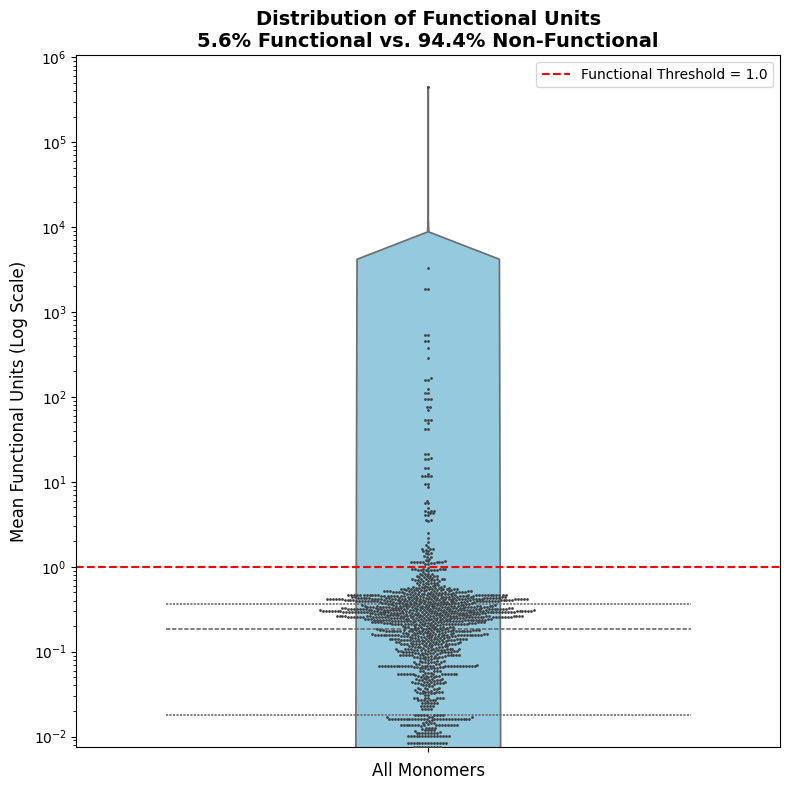

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_functional_unit_distribution(df, threshold=1.0):
    """
    Generates a violin plot to show the distribution of functional units,
    annotated with the percentage of functional vs. non-functional monomers.
    """
    plt.figure(figsize=(8, 8))
    
    # Create a violin plot for all monomers
    ax = sns.violinplot(y=df['mean_functional_units'], color="skyblue", inner="quartile")
    
    # Add a swarm plot to show individual data points
    sns.swarmplot(y=df['mean_functional_units'], color=".25", size=2, ax=ax)

    # Add and label the functional threshold line
    ax.axhline(threshold, ls='--', color='red', label=f'Functional Threshold = {threshold}')
    
    # Calculate and display the percentage of functional/non-functional monomers
    is_functional = df['mean_functional_units'] >= threshold
    pct_functional = 100 * is_functional.sum() / len(df)
    
    title = (f'Distribution of Functional Units\n'
             f'{pct_functional:.1f}% Functional vs. {100 - pct_functional:.1f}% Non-Functional')
    
    # Final plot adjustments
    ax.set_yscale('log')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('All Monomers', fontsize=12)
    ax.set_ylabel('Mean Functional Units (Log Scale)', fontsize=12)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Load data and call the plotting function
file_path = '/user/home/il22158/work/vEcoli/reading/results/functional_gene/all_media_conditions1_functional_genes_v0_mean.csv'
df_functional_genes = pd.read_csv(file_path)
plot_functional_unit_distribution(df_functional_genes, threshold=1.0)


In [4]:

import pandas as pd
import plotly.graph_objects as go
from plotly.offline import iplot, init_notebook_mode

# Ensure Plotly works in the notebook
init_notebook_mode(connected=True)

# Load the data
file_path = '/user/home/il22158/work/vEcoli/reading/results/functional_gene/all_media_conditions1_functional_genes_v0_mean.csv'
df = pd.read_csv(file_path)

# --- 1. Create the main plot ---
fig = go.Figure()

# Add violin plot to show the data distribution.
# The points='all' parameter adds a swarm plot to show individual data points.
fig.add_trace(go.Violin(
    y=df['mean_functional_units'],
    name='Functional Units',
    box_visible=True,
    meanline_visible=True,
    points='all'
))

# Add a transparent trace for the legend entry of the threshold line
fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='lines',
    line=dict(color="Red", width=2, dash="dashdot"),
    name='Threshold'
))


# --- 2. Create the slider and its steps ---
steps = []
# Create a step for each threshold value from 0.1 to 2.0
for i in range(1, 21):
    threshold = i * 0.1
    
    # Calculate percentages for the current threshold
    is_functional = df['mean_functional_units'] >= threshold
    pct_functional = 100 * is_functional.sum() / len(df)
    
    # Define what happens when the slider is moved to this step
    step = dict(
        method="update",
        # Update the threshold line's position and the plot's title
        args=[
            {"shapes[0].y0": threshold, "shapes[0].y1": threshold},
            {"title": f"Distribution of Functional Units (Threshold: {threshold:.1f})<br>"
                      f"<sup>{pct_functional:.1f}% Functional vs. {100 - pct_functional:.1f}% Non-Functional</sup>"}
        ],
        label=f"{threshold:.1f}"
    )
    steps.append(step)

sliders = [dict(
    active=9,  # Set the default position to a threshold of 1.0
    currentvalue={"prefix": "Threshold: "},
    pad={"t": 50}, # Add padding to avoid overlap with title
    steps=steps
)]


# --- 3. Configure the plot's layout, title, and initial state ---
initial_threshold = 1.0
is_functional_initial = df['mean_functional_units'] >= initial_threshold
pct_functional_initial = 100 * is_functional_initial.sum() / len(df)

fig.update_layout(
    # Set the initial title
    title=f"Distribution of Functional Units (Threshold: {initial_threshold:.1f})<br>"
          f"<sup>{pct_functional_initial:.1f}% Functional vs. {100 - pct_functional_initial:.1f}% Non-Functional</sup>",
    
    # Configure axes and slider
    yaxis_title="Mean Functional Units (Log Scale)",
    yaxis_type="log",
    xaxis_title="All Monomers",
    sliders=sliders,
    
    # Add the initial red dashed line for the threshold
    shapes=[
        go.layout.Shape(
            type="line",
            x0=-1, x1=1, # Line spans the width of the plot
            y0=initial_threshold, y1=initial_threshold,
            line=dict(color="Red", width=2, dash="dashdot")
        )
    ]
)

# Save the interactive plot to an HTML file
html_output_path = '/user/home/il22158/work/vEcoli/reading/results/functional_gene/interactive_functional_units.html'
fig.write_html(html_output_path)

print(f"✓ Interactive plot saved to: {html_output_path}")

# Show the plot in the notebook
iplot(fig)


✓ Interactive plot saved to: /user/home/il22158/work/vEcoli/reading/results/functional_gene/interactive_functional_units.html


In [1]:
import pandas as pd
import plotly.graph_objects as go
from plotly.offline import iplot, init_notebook_mode
import numpy as np

# Ensure Plotly works in the notebook
init_notebook_mode(connected=True)

# --- 1. Create a subset of the data ---
# Load the original data 
file_path = '/user/home/il22158/work/vEcoli/reading/results/functional_gene/all_media_conditions1_functional_genes_v0_mean.csv'
df_full = pd.read_csv(file_path)

# Filter for the "non-functional" subset where the value is less than 1.0
df_subset = df_full[df_full['mean_functional_units'] < 1.0].copy()

print(f'Original dataset: {len(df_full)} samples')
print(f'Non-functional subset (<1.0): {len(df_subset)} samples ({100*len(df_subset)/len(df_full):.1f}%)')
print()

# --- 2. Create the main plot for the subset ---
fig_subset = go.Figure()

# Add violin plot for the subset distribution
fig_subset.add_trace(go.Violin(
    y=df_subset['mean_functional_units'],
    name='Non-Functional Units (<1.0)',
    box_visible=True,
    meanline_visible=True,
    points='all'
))

# Add a transparent trace for the legend entry of the threshold line
fig_subset.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='lines',
    line=dict(color="Blue", width=2, dash="dashdot"),
    name='Sub-Threshold'
))

# --- 3. Create the slider for the subset ---
steps_subset = []
# Create steps for a more focused range, from 0.05 to 0.95 in steps of 0.05
for i in np.arange(0.05, 1.0, 0.05):
    threshold = round(i, 2)
    
    # Calculate percentages *within the subset*
    is_above_sub_threshold = df_subset['mean_functional_units'] >= threshold
    pct_above = 100 * is_above_sub_threshold.sum() / len(df_subset)
    
    step = dict(
        method="update",
        args=[
            {"shapes[0].y0": threshold, "shapes[0].y1": threshold},
            {"title": f"Distribution of Non-Functional Subset (Sub-Threshold: {threshold:.2f})<br>"
                      f"<sup>{pct_above:.1f}% above sub-threshold vs. {100 - pct_above:.1f}% below</sup>"}
        ],
        label=f"{threshold:.2f}"
    )
    steps_subset.append(step)

sliders_subset = [dict(
    active=9,  # Default to a sub-threshold of 0.50
    currentvalue={"prefix": "Sub-Threshold: "},
    pad={"t": 50},
    steps=steps_subset
)]

# --- 4. Configure the plot's layout for the subset ---
initial_threshold_subset = 0.5
is_above_initial_subset = df_subset['mean_functional_units'] >= initial_threshold_subset
pct_above_initial_subset = 100 * is_above_initial_subset.sum() / len(df_subset)

fig_subset.update_layout(
    title=f"Distribution of Non-Functional Subset (Sub-Threshold: {initial_threshold_subset:.2f})<br>"
          f"<sup>{pct_above_initial_subset:.1f}% above sub-threshold vs. {100 - pct_above_initial_subset:.1f}% below</sup>",
    yaxis_title="Mean Functional Units",
    xaxis_title="Monomers with Mean Functional Units < 1.0",
    sliders=sliders_subset,
    shapes=[
        go.layout.Shape(
            type="line",
            x0=-1, x1=1,
            y0=initial_threshold_subset, y1=initial_threshold_subset,
            line=dict(color="Blue", width=2, dash="dashdot")
        )
    ]
)

# Save the new interactive plot to a separate HTML file
html_output_path_subset = '/user/home/il22158/work/vEcoli/reading/results/functional_gene/interactive_non_functional_units.html'
fig_subset.write_html(html_output_path_subset)

print(f"✓ Interactive plot for non-functional subset saved to: {html_output_path_subset}")

# Show the plot in the notebook
iplot(fig_subset)

Original dataset: 1636 samples
Non-functional subset (<1.0): 1545 samples (94.4%)

✓ Interactive plot for non-functional subset saved to: /user/home/il22158/work/vEcoli/reading/results/functional_gene/interactive_non_functional_units.html


## Growth rate data

In [5]:
# Extract growth rate data from vEcoli simulations (based on multi_gen_plot.py)

import pandas as pd
import numpy as np
import glob
import json

def extract_growth_rate_data(project_folder, variant_key="condition", generation=1, 
                             read_interval_sec=20, max_variants=None, save_timeseries=False):
    """
    Extract growth rate metrics from vEcoli simulation data.
    
    Parameters:
    -----------
    project_folder : str
        Name of the project folder (e.g., "all_media_conditions1")
    variant_key : str
        Key in metadata for variant information
    generation : int or list
        Generation(s) to extract. If list, data is averaged across generations
    read_interval_sec : int
        Downsample data (take 1 point every N seconds). Default=20
    max_variants : int or None
        Max variants to extract (for testing). None = all
    save_timeseries : bool
        If True, save all timepoints to parquet. If False, return summary only
    
    Returns:
    --------
    df_growth : pd.DataFrame
        Summary statistics or full timeseries data
    """
    
    # Convert generation to list
    gen_list = [generation] if isinstance(generation, int) else list(generation)
    
    # Load metadata
    metadata_file = f'/user/home/il22158/work/vEcoli/out/{project_folder}/variant_sim_data/metadata.json'
    try:
        with open(metadata_file, 'r') as f:
            metadata = json.load(f)
        variant_metadata = metadata.get(variant_key, {})
        variant_ids = sorted([int(k) for k in variant_metadata.keys()])
        if max_variants:
            variant_ids = variant_ids[:max_variants]
    except FileNotFoundError:
        print(f'❌ Metadata not found: {project_folder}')
        return pd.DataFrame()
    
    # Extract data for each variant
    all_data = []
    
    for variant_id in variant_ids:
        # Get label
        v_info = variant_metadata.get(str(variant_id), f'variant_{variant_id}')
        if isinstance(v_info, str):
            label = v_info
        elif isinstance(v_info, dict):
            genes = v_info.get('genes_to_knockout', [])
            label = f"KO: {', '.join(genes)}" if genes else v_info.get('condition', str(v_info))
        else:
            label = f'variant_{variant_id}'
        
        # Load data from all generations
        gen_data = []
        for gen in gen_list:
            agent_id = "0" * gen
            base_path = f'/user/home/il22158/work/vEcoli/out/{project_folder}/history/experiment_id={project_folder}/variant={variant_id}/lineage_seed=0/generation={gen}/agent_id={agent_id}'
            pq_files = sorted(glob.glob(f'{base_path}/*.pq'))
            
            if not pq_files:
                continue
            
            # Load and downsample
            dfs = []
            for pq_file in pq_files:
                df_temp = pd.read_parquet(pq_file)
                if read_interval_sec and read_interval_sec > 1:
                    df_temp = df_temp.iloc[::read_interval_sec]
                dfs.append(df_temp)
            
            df_gen = pd.concat(dfs, ignore_index=True).sort_values('time').reset_index(drop=True)
            gen_data.append(df_gen)
        
        if not gen_data:
            continue
        
        # Concatenate generations
        df_all = pd.concat(gen_data, ignore_index=True)
        
        if save_timeseries:
            # Save all timepoints
            df_all['project'] = project_folder
            df_all['variant'] = variant_id
            df_all['label'] = label
            all_data.append(df_all[['project', 'variant', 'label', 'time', 
                                    'listeners__mass__instantaneous_growth_rate',
                                    'listeners__mass__dry_mass']])
        else:
            # Calculate summary statistics
            growth_rate = df_all['listeners__mass__instantaneous_growth_rate'].values
            dry_mass = df_all['listeners__mass__dry_mass'].values
            time_vals = df_all['time'].values
            
            all_data.append({
                'project': project_folder,
                'variant': variant_id,
                'label': label,
                'mean_growth_rate': np.mean(growth_rate),
                'median_growth_rate': np.median(growth_rate),
                'std_growth_rate': np.std(growth_rate),
                'initial_dry_mass': dry_mass[0],
                'final_dry_mass': dry_mass[-1],
                'fold_change_mass': dry_mass[-1] / dry_mass[0],
                'duration_sec': time_vals[-1] - time_vals[0],
                'n_timepoints': len(df_all),
                'generations_used': len(gen_list)
            })
    
    # Create DataFrame
    if save_timeseries and all_data:
        df_growth = pd.concat(all_data, ignore_index=True)
    else:
        df_growth = pd.DataFrame(all_data)
    
    if len(df_growth) > 0:
        gen_str = f'{len(gen_list)} gens' if len(gen_list) > 1 else f'gen {gen_list[0]}'
        data_type = 'timeseries' if save_timeseries else 'summary'
        print(f'✓ {project_folder}: {len(all_data)} variants, {gen_str}, {data_type}')
    
    return df_growth

print('Function ready: extract_growth_rate_data()')
print('Parameters: project_folder, variant_key, generation, read_interval_sec=20')
print('Set save_timeseries=True to save all timepoints')


Function ready: extract_growth_rate_data()
Parameters: project_folder, variant_key, generation, read_interval_sec=20
Set save_timeseries=True to save all timepoints


In [ ]:
# TRIAL: 2 variants × 2 generations × 3 projects

projects = [
    {'folder': 'all_media_conditions1', 'variant_key': 'condition'},
    {'folder': 'gene_knockout_metabolic1', 'variant_key': 'gene_knockout'},
    {'folder': 'gene_knockout_non_metabolic1', 'variant_key': 'gene_knockout'}
]

print('TRIAL RUN: 2 variants × 2 gens × 3 projects (downsampled every 20s)')
print('=' * 80)

# Extract summary statistics
all_summary = []
for proj in projects:
    df = extract_growth_rate_data(proj['folder'], proj['variant_key'], 
                                  generation=[1,2], max_variants=2, save_timeseries=False)
    if len(df) > 0:
        all_summary.append(df)

df_summary = pd.concat(all_summary, ignore_index=True)
print()
print(df_summary[['project', 'variant', 'label', 'mean_growth_rate', 'fold_change_mass', 'n_timepoints']].to_string(index=False))

# Save summary
df_summary.to_csv('/user/home/il22158/work/vEcoli/reading/results/growth_rate_combined.csv', index=False)
print()
print('✓ Saved: growth_rate_combined.csv')

# Extract full timeseries
print('\n' + '=' * 80)
print('Extracting full timeseries data...')
all_timeseries = []
for proj in projects:
    df = extract_growth_rate_data(proj['folder'], proj['variant_key'],
                                  generation=[1,2], max_variants=2, save_timeseries=True)
    if len(df) > 0:
        all_timeseries.append(df)

df_timeseries = pd.concat(all_timeseries, ignore_index=True)
df_timeseries.to_parquet('/user/home/il22158/work/vEcoli/reading/results/growth_rate_timeseries.parquet', index=False)
print(f'✓ Saved: growth_rate_timeseries.parquet ({len(df_timeseries)} timepoints)')
print('=' * 80)


TRIAL RUN: 2 variants × 2 gens × 3 projects (downsampled every 20s)
✓ all_media_conditions1: 2 variants, 2 gens, summary
✓ gene_knockout_metabolic1: 2 variants, 2 gens, summary
✓ gene_knockout_non_metabolic1: 2 variants, 2 gens, summary

                     project  variant       label  mean_growth_rate  fold_change_mass  n_timepoints
       all_media_conditions1        0    baseline          0.000242          1.819478           268
       all_media_conditions1        1     with_aa          0.000382          2.767096           218
    gene_knockout_metabolic1        1 KO: EG10003          0.000238          1.849102           268
    gene_knockout_metabolic1        2 KO: EG10013          0.000238          1.874614           269
gene_knockout_non_metabolic1        1 KO: EG10001          0.000238          1.772768           264
gene_knockout_non_metabolic1        2 KO: EG10004          0.000247          1.842027           264

✓ Saved: growth_rate_combined.csv

Extracting full timeseries

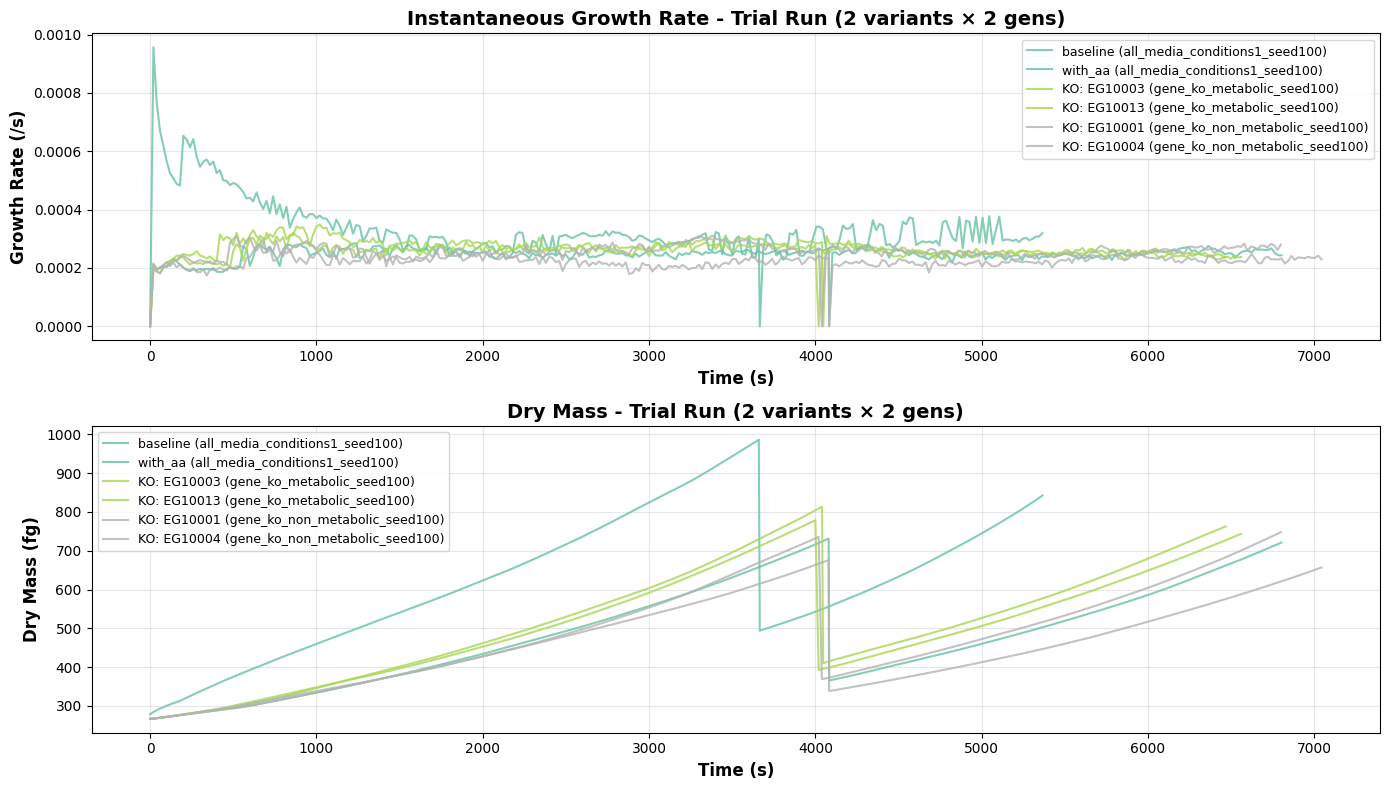

✓ Figure saved: growth_curves_seed100_trial.png


In [ ]:
# Visualize growth rate curves across all projects (like multi_gen_plot.py)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

# Load timeseries data for plotting
timeseries_file = '/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_trial.parquet'
try:
    df_timeseries = pd.read_parquet(timeseries_file)
    
    # Plot growth curves
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Get unique projects and assign colors
    projects_list = df_timeseries['project'].unique()
    colors = plt.cm.Set2(np.linspace(0, 1, len(projects_list)))
    project_colors = {proj: colors[i] for i, proj in enumerate(projects_list)}
    
    # Plot each variant
    variants = df_timeseries.groupby(['project', 'variant', 'label'])
    
    for (proj, var_id, label), group in variants:
        color = project_colors[proj]
        
        # Growth rate curve
        ax1.plot(group['time'], 
                group['listeners__mass__instantaneous_growth_rate'],
                linewidth=1.5, color=color, alpha=0.8, label=f'{label} ({proj})')
        
        # Dry mass curve
        ax2.plot(group['time'],
                group['listeners__mass__dry_mass'],
                linewidth=1.5, color=color, alpha=0.8, label=f'{label} ({proj})')
    
    # Format plots
    ax1.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Growth Rate (/s)', fontsize=12, fontweight='bold')
    ax1.set_title('Instantaneous Growth Rate - Trial Run (2 variants × 2 gens)', 
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    ax2.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Dry Mass (fg)', fontsize=12, fontweight='bold')
    ax2.set_title('Dry Mass - Trial Run (2 variants × 2 gens)', 
                  fontsize=14, fontweight='bold')
    ax2.legend(loc='best', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_curves_seed100_trial.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print('✓ Figure saved: growth_curves_seed100_trial.png')
    
except FileNotFoundError:
    print('⚠ Timeseries data not found. Run cell 3 to extract data first.')

## Correlation study for Bio-Informed ANN Design


**Goal**: Validate the proposed layer structure by measuring information flow between layers using mutual information.

**Analysis Plan**:
1. **Input → Layer 1**: MI between (media + gene knockouts) and (transcription/translation success)
2. **Layer 1 → Layer 2**: MI between (success counts) and (mRNA/protein expression)  
3. **Layer 2 → Output**: MI between (expression profiles) and (growth rate)

**Expected Results**:
- High MI between layers → justifies bio-informed architecture
- Low MI → suggests layer may not add predictive value
- Asymmetric MI patterns → reveals which genes/pathways are most informative

**Data Requirements**:
- Gene expression data (40 genes): transcription/translation success, mRNA/protein levels
- Media conditions (5 types, one-hot encoded)
- Gene knockout indicators (40-300 binary features)
- Growth rate (to be extracted from vEcoli simulations)

In [ ]:
# OPTIMIZED DATA LOADING - All scalar gene expression data with growth rates

import pandas as pd
import numpy as np
import glob
from pathlib import Path

def load_all_gene_expression_data():
    """
    Efficiently load all gene expression data from both directories.
    Data is scalar (already aggregated), not time-series.
    """
    # Directories containing gene expression data
    data_dirs = [
        # '/user/home/il22158/work/vEcoli/reading/results/gene_activity_screen1',
        '/user/home/il22158/work/vEcoli/reading/results/gene_activity_screen'
    ]
    
    # Find all files with _40genes suffix
    all_files = []
    for data_dir in data_dirs:
        pattern = f'{data_dir}/*_40genes.csv'
        all_files.extend(glob.glob(pattern))
    
    print(f'Found {len(all_files)} gene expression files')
    
    # Load and concatenate all files efficiently
    dfs = []
    for file in all_files:
        # Extract project name from filename
        filename = Path(file).stem  # e.g., all_media_conditions1_variant0_40genes
        parts = filename.replace('_40genes', '').rsplit('_variant', 1)
        project = parts[0]
        
        df_temp = pd.read_csv(file)
        df_temp['project'] = project
        dfs.append(df_temp)
    
    # Combine all data
    df_all = pd.concat(dfs, ignore_index=True)
    
    print(f'✓ Loaded {len(df_all)} gene×variant combinations')
    print(f'  Projects: {df_all["project"].nunique()} ({", ".join(df_all["project"].unique())})')
    print(f'  Variants per project: {df_all.groupby("project")["variant"].nunique().to_dict()}')
    print(f'  Genes: {df_all["gene_id"].nunique()}')
    
    return df_all

def merge_with_growth_rate(df_gene):
    """
    Merge gene expression data with growth rate data.
    Growth rate is per variant (not per gene), so expand to match.
    """
    # Load growth rate data
    growth_file = '/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_default_all.csv'
    df_growth = pd.read_csv(growth_file)
    
    print(f'\n✓ Loaded growth rate data: {len(df_growth)} variants')
    
    # Merge on project and variant
    df_merged = df_gene.merge(
        df_growth[['project', 'variant', 'mean_growth_rate', 'median_growth_rate', 
                   'fold_change_mass', 'duration_sec']],
        on=['project', 'variant'],
        how='left'
    )
    
    matched = df_merged['mean_growth_rate'].notna().sum()
    print(f'✓ Merged: {matched}/{len(df_merged)} rows matched ({matched/len(df_merged)*100:.1f}%)')
    
    return df_merged

# Load all data
print('=' * 80)
print('LOADING ALL GENE EXPRESSION DATA (SCALAR VALUES)')
print('=' * 80)
df = load_all_gene_expression_data()

# Merge with growth rates
df = merge_with_growth_rate(df)

# Display overview
print(f'\n{"=" * 80}')
print('FINAL DATASET OVERVIEW')
print('=' * 80)
print(f'Shape: {df.shape[0]} samples × {df.shape[1]} features')
print(f'\nColumns:')
for col in df.columns:
    print(f'  - {col}')

print(f'\nSample data (first 3 rows):')
print(df.head(3))

print(f'\nData summary:')
print(f'  Unique projects: {df["project"].nunique()}')
print(f'  Unique variants: {df["variant"].nunique()}')
print(f'  Unique genes: {df["gene_id"].nunique()}')
print(f'  Growth rate range: {df["mean_growth_rate"].min():.6f} to {df["mean_growth_rate"].max():.6f} /s')
print('=' * 80)

### Step 1: Prepare Layer Features

Extract and organize data according to the proposed ANN architecture:
- **Input Layer**: Media condition (5 types) + Gene knockout indicators (40 binary features)
  - Note: `gene_knockout_metabolic1` and `gene_knockout_non_metabolic1` use baseline media (variant 0)
- **Layer 1**: Transcription success + Translation success **for each gene** (40 genes × 2 = 80 features)
- **Layer 2**: max_mrna, mean_mrna, max_protein, mean_protein **for each gene** (40 genes × 4 = 160 features)
- **Output**: Growth rate (scalar)

The data must be **reshaped** from long format (one row per gene×variant) to wide format (one row per variant).

In [ ]:
# OPTIMIZED: Prepare features for each layer of the bio-informed ANN
# CORRECTED: Reshape data to have one row per variant with all genes as features

from sklearn.preprocessing import LabelEncoder

# Check if growth rate data exists
has_growth_data = df['mean_growth_rate'].notna().any()

if not has_growth_data:
    print('⚠ WARNING: No growth rate data found.')
    
print('\n' + '=' * 80)
print('PREPARING ANN LAYER FEATURES (BIO-INFORMED ARCHITECTURE)')
print('=' * 80)

# Determine media conditions correctly
df['media_condition'] = df.apply(
    lambda row: row['variant'] if row['project'] == 'all_media_conditions1' else 0, 
    axis=1
)

# Create unique variant key and remove duplicates
df['variant_key'] = df['project'] + '_v' + df['variant'].astype(str)
df_unique = df.drop_duplicates(subset=['variant_key', 'gene_id']).copy()

print(f'Data reshaping:')
print(f'  Original: {len(df)} rows → Unique: {len(df_unique)} rows')
print(f'  Variants: {df_unique["variant_key"].nunique()}')
print(f'  Genes per variant: {df_unique.groupby("variant_key")["gene_id"].count().mean():.0f}')

# Pivot data efficiently
pivot_trans = df_unique.pivot(index='variant_key', columns='gene_id', values='all_transcription_success')
pivot_transl = df_unique.pivot(index='variant_key', columns='gene_id', values='all_translation_success')
pivot_max_mrna = df_unique.pivot(index='variant_key', columns='gene_id', values='max_mrna')
pivot_mean_mrna = df_unique.pivot(index='variant_key', columns='gene_id', values='mean_mrna')
pivot_max_protein = df_unique.pivot(index='variant_key', columns='gene_id', values='max_protein')
pivot_mean_protein = df_unique.pivot(index='variant_key', columns='gene_id', values='mean_protein')

# Rename columns
all_genes = sorted(df_unique['gene_id'].unique())
pivot_trans.columns = [f'{g}_trans' for g in pivot_trans.columns]
pivot_transl.columns = [f'{g}_transl' for g in pivot_transl.columns]
pivot_max_mrna.columns = [f'{g}_max_mrna' for g in pivot_max_mrna.columns]
pivot_mean_mrna.columns = [f'{g}_mean_mrna' for g in pivot_mean_mrna.columns]
pivot_max_protein.columns = [f'{g}_max_prot' for g in pivot_max_protein.columns]
pivot_mean_protein.columns = [f'{g}_mean_prot' for g in pivot_mean_protein.columns]

# Get metadata for each variant
variant_meta = df_unique.groupby('variant_key').first()[['project', 'variant', 'media_condition', 'mean_growth_rate']]

# Create input features
media_dummies = pd.get_dummies(variant_meta['media_condition'], prefix='media', dtype=int)

# Gene knockout indicators
knockout_matrix = pd.DataFrame(0, index=variant_meta.index, columns=[f'KO_{g}' for g in all_genes])
for vk in variant_meta.index:
    proj = variant_meta.loc[vk, 'project']
    if 'gene_knockout' in proj:
        # Extract knocked out gene from project name
        ko_gene = df_unique[df_unique['variant_key'] == vk]['gene_id'].iloc[0]
        knockout_matrix.loc[vk, f'KO_{ko_gene}'] = 1

input_features = pd.concat([media_dummies, knockout_matrix], axis=1)

# Layer features
layer1_features = pd.concat([pivot_trans, pivot_transl], axis=1)
layer2_features = pd.concat([pivot_max_mrna, pivot_mean_mrna, pivot_max_protein, pivot_mean_protein], axis=1)

# Output
if has_growth_data:
    output_feature = variant_meta['mean_growth_rate'].copy()
    output_label = 'Mean Growth Rate (/s)'
    mask = output_feature.notna()
    input_features = input_features[mask]
    layer1_features = layer1_features[mask]
    layer2_features = layer2_features[mask]
    output_feature = output_feature[mask]
    print(f'\nFiltered to {len(output_feature)} variants with growth rate data')
else:
    output_feature = pivot_mean_protein.mean(axis=1)
    output_label = 'Mean Protein (proxy)'

print(f'\nLAYER ARCHITECTURE (BIO-INFORMED):')
print(f'  Input:  {input_features.shape[1]} ({media_dummies.shape[1]} media + {knockout_matrix.shape[1]} KO)')
print(f'  Layer1: {layer1_features.shape[1]} (2 × {len(all_genes)} genes)')
print(f'  Layer2: {layer2_features.shape[1]} (4 × {len(all_genes)} genes)')
print(f'  Output: 1 ({output_label})')
print(f'  Samples: {len(output_feature)}')
print('=' * 80)


PREPARING ANN LAYER FEATURES (BIO-INFORMED ARCHITECTURE)
Data reshaping:
  Original: 1800 rows → Unique: 1800 rows
  Variants: 45
  Genes per variant: 40

Filtered to 45 variants with growth rate data

LAYER ARCHITECTURE (BIO-INFORMED):
  Input:  45 (5 media + 40 KO)
  Layer1: 80 (2 × 40 genes)
  Layer2: 160 (4 × 40 genes)
  Output: 1 (Mean Growth Rate (/s))
  Samples: 45


### Step 2: Mutual Information Analysis - Input → Layer 1

Calculate MI between input features (media + gene knockouts) and Layer 1 (transcription/translation success).

**Interpretation**:
- High MI → Input strongly predicts transcription/translation success
- Low MI → Weak predictive relationship (may need more features or different encoding)


MUTUAL INFORMATION ANALYSIS: INPUT → LAYER 1

Average MI to Layer 1 (across 80 genes):
  Transcription: Mean=0.0221, Max=0.1992
  Translation:   Mean=0.0253, Max=0.1412

Top 5 inputs for transcription (averaged across genes):
  KO_EG10001                     MI=0.1992
  media_0                        MI=0.1775
  KO_EG10112                     MI=0.0629
  KO_EG10129                     MI=0.0499
  KO_EG10018                     MI=0.0498

Top 5 inputs for translation (averaged across genes):
  media_0                        MI=0.1412
  KO_EG10001                     MI=0.1148
  KO_EG10112                     MI=0.0985
  KO_EG10129                     MI=0.0870
  KO_EG10018                     MI=0.0822


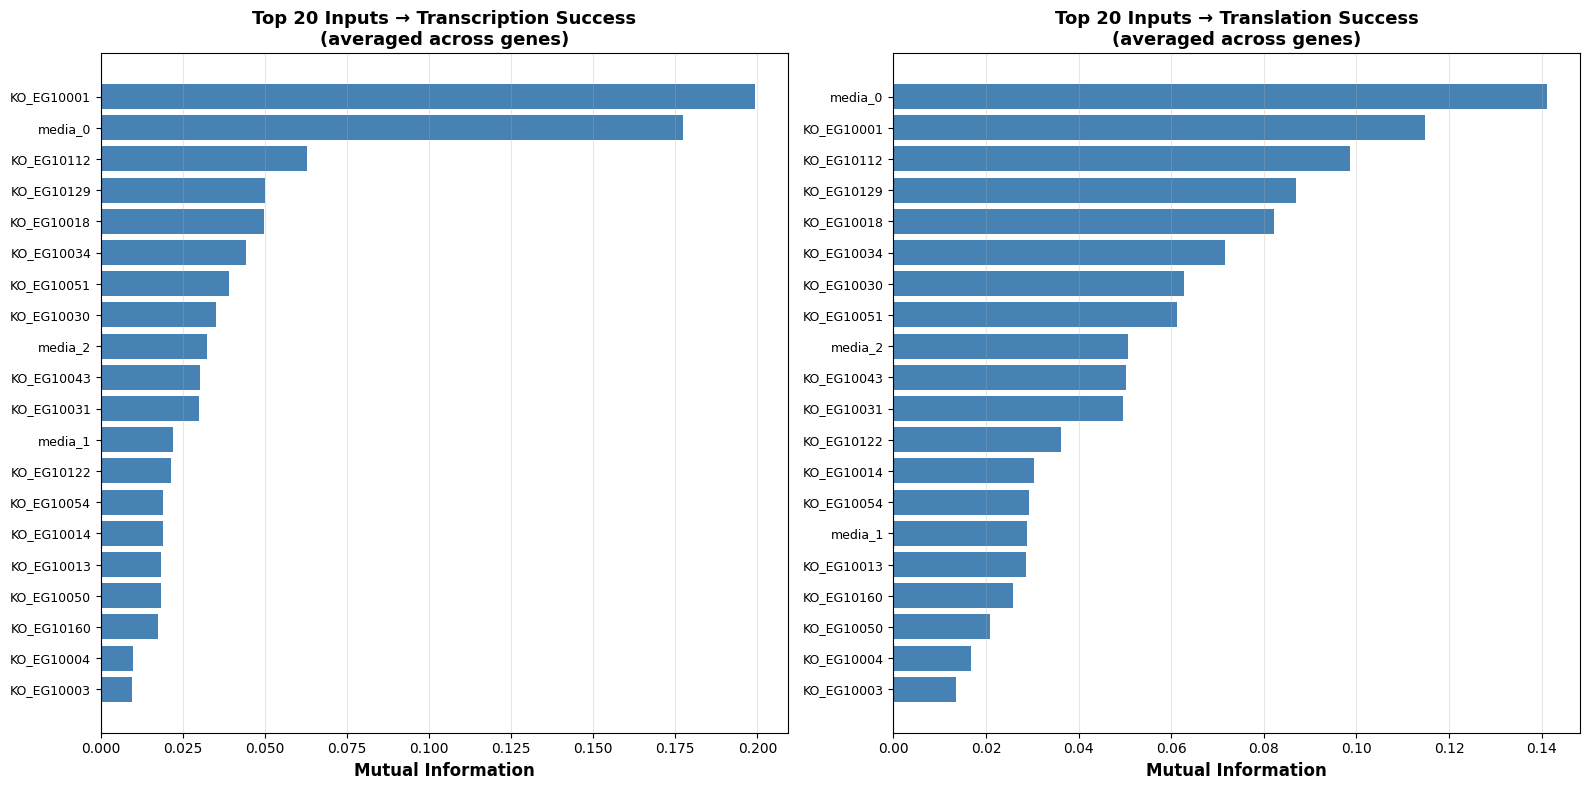


✓ Saved: MI/input_to_layer1_detailed.csv
✓ Saved: MI/input_to_layer1.png


In [ ]:
# OPTIMIZED: Mutual Information - Input → Layer 1

import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
import os

print('\n' + '=' * 80)
print('MUTUAL INFORMATION ANALYSIS: INPUT → LAYER 1')
print('=' * 80)

# Calculate MI for all Layer 1 features
mi_input_to_layer1 = {}
for col in layer1_features.columns:
    mi_scores = mutual_info_regression(input_features, layer1_features[col], 
                                       random_state=42, n_neighbors=3)
    mi_input_to_layer1[col] = mi_scores

# Create summary DataFrame
mi_df_input_layer1 = pd.DataFrame(mi_input_to_layer1, index=input_features.columns)

# Save detailed results
os.makedirs('/user/home/il22158/work/vEcoli/reading/results/MI', exist_ok=True)
mi_df_input_layer1.to_csv('/user/home/il22158/work/vEcoli/reading/results/MI/input_to_layer1_detailed.csv')

# Aggregate by feature type (transcription vs translation)
trans_cols = [c for c in layer1_features.columns if '_trans' in c]
transl_cols = [c for c in layer1_features.columns if '_transl' in c]

mi_transcription_avg = mi_df_input_layer1[trans_cols].mean(axis=1)
mi_translation_avg = mi_df_input_layer1[transl_cols].mean(axis=1)

print(f'\nAverage MI to Layer 1 (across {len(trans_cols)} genes):')
print(f'  Transcription: Mean={mi_transcription_avg.mean():.4f}, Max={mi_transcription_avg.max():.4f}')
print(f'  Translation:   Mean={mi_translation_avg.mean():.4f}, Max={mi_translation_avg.max():.4f}')

# Top input features
print('\nTop 5 inputs for transcription (averaged across genes):')
for feat, mi_val in mi_transcription_avg.nlargest(5).items():
    print(f'  {feat:30s} MI={mi_val:.4f}')

print('\nTop 5 inputs for translation (averaged across genes):')
for feat, mi_val in mi_translation_avg.nlargest(5).items():
    print(f'  {feat:30s} MI={mi_val:.4f}')

# Visualize aggregated MI
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, (mi_avg, title) in enumerate([(mi_transcription_avg, 'Transcription Success'), 
                                        (mi_translation_avg, 'Translation Success')]):
    top20 = mi_avg.nlargest(20)
    axes[idx].barh(range(len(top20)), top20.values, color='steelblue')
    axes[idx].set_yticks(range(len(top20)))
    axes[idx].set_yticklabels(top20.index, fontsize=9)
    axes[idx].set_xlabel('Mutual Information', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'Top 20 Inputs → {title}\n(averaged across genes)', fontsize=13, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.savefig('/user/home/il22158/work/vEcoli/reading/results/MI/input_to_layer1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Saved: MI/input_to_layer1_detailed.csv')
print('✓ Saved: MI/input_to_layer1.png')
print('=' * 80)

### Step 3: Mutual Information Analysis - Layer 1 → Layer 2

Calculate MI between Layer 1 (transcription/translation success) and Layer 2 (mRNA/protein expression).

**Biological Hypothesis**:
- Transcription success should correlate with mRNA levels
- Translation success should correlate with protein levels
- High MI validates the biological flow: success → expression

In [2]:
# MI: Layer 1 → Layer 2 (Focus on own-gene relationships)

# Import seaborn if not already loaded
if 'sns' not in locals():
    import seaborn as sns

print('\n' + '=' * 80)
print('MUTUAL INFORMATION: LAYER 1 → LAYER 2')
print('Focus: Does each gene\'s success predict its OWN expression?')
print('=' * 80)

# Check if previous cells were run
if 'layer1_features' not in locals() or 'layer2_features' not in locals():
    print('⚠ ERROR: Please run previous cells first (data loading and layer preparation)')
    print('=' * 80)
else:
    # Calculate MI for all Layer 1 → Layer 2 relationships
    mi_layer1_to_layer2 = {}
    for col in layer2_features.columns:
        mi_scores = mutual_info_regression(layer1_features, layer2_features[col],
                                           random_state=42, n_neighbors=3)
        mi_layer1_to_layer2[col] = mi_scores

    mi_df_full = pd.DataFrame(mi_layer1_to_layer2, index=layer1_features.columns)
    mi_df_full.to_csv('/user/home/il22158/work/vEcoli/reading/results/MI/layer1_to_layer2_full.csv')

    # Extract per-gene own-gene relationships
    genes = sorted(set([col.split('_')[0] for col in layer1_features.columns]))
    print(f'\nAnalyzing {len(genes)} genes\n')

    # Build matrix: rows=genes, columns=4 key relationships
    own_gene_mi = []
    for gene in genes:
        # Layer 1 features for this gene
        trans = f'{gene}_trans'
        transl = f'{gene}_transl'
        
        # Layer 2 features for this gene
        max_mrna = f'{gene}_max_mrna'
        mean_mrna = f'{gene}_mean_mrna'
        max_prot = f'{gene}_max_prot'
        mean_prot = f'{gene}_mean_prot'
        
        if trans in mi_df_full.index and max_mrna in mi_df_full.columns:
            own_gene_mi.append({
                'Gene': gene,
                'Trans→mRNA_max': mi_df_full.loc[trans, max_mrna],
                'Trans→mRNA_mean': mi_df_full.loc[trans, mean_mrna],
                'Transl→Prot_max': mi_df_full.loc[transl, max_prot],
                'Transl→Prot_mean': mi_df_full.loc[transl, mean_prot]
            })

    df_own_gene = pd.DataFrame(own_gene_mi)
    df_own_gene.to_csv('/user/home/il22158/work/vEcoli/reading/results/MI/layer1_to_layer2_own_gene.csv', index=False)

    # Display top genes by biological relevance
    df_own_gene['mRNA_signal'] = df_own_gene[['Trans→mRNA_max', 'Trans→mRNA_mean']].mean(axis=1)
    df_own_gene['Prot_signal'] = df_own_gene[['Transl→Prot_max', 'Transl→Prot_mean']].mean(axis=1)
    df_own_gene['Total_signal'] = df_own_gene['mRNA_signal'] + df_own_gene['Prot_signal']

    print('Top 10 genes with strongest own-gene MI signal:')
    print(df_own_gene.nlargest(10, 'Total_signal')[['Gene', 'mRNA_signal', 'Prot_signal', 'Total_signal']].to_string(index=False))

    # Heatmap: Each gene × 4 relationships
    fig, ax = plt.subplots(figsize=(10, max(8, len(genes) * 0.3)))
    plot_data = df_own_gene.set_index('Gene')[['Trans→mRNA_max', 'Trans→mRNA_mean', 
                                                 'Transl→Prot_max', 'Transl→Prot_mean']]

    sns.heatmap(plot_data, annot=True, fmt='.3f', cmap='YlOrRd',
                cbar_kws={'label': 'Mutual Information'}, linewidths=1, ax=ax)
    ax.set_title('Layer 1 → Layer 2: Own-Gene Relationships\n(Each gene\'s success → its own expression)', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Success Type → Expression Type', fontsize=11, fontweight='bold')
    ax.set_ylabel('Gene', fontsize=11, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('/user/home/il22158/work/vEcoli/reading/results/MI/layer1_to_layer2_heatmap.png', 
                dpi=150, bbox_inches='tight')
    plt.show()

    # Summary statistics
    print(f'\nSummary Statistics (averaged across {len(genes)} genes):')
    print(f'  Transcription → mRNA:  {df_own_gene["mRNA_signal"].mean():.4f} ± {df_own_gene["mRNA_signal"].std():.4f}')
    print(f'  Translation → Protein: {df_own_gene["Prot_signal"].mean():.4f} ± {df_own_gene["Prot_signal"].std():.4f}')

    if df_own_gene["mRNA_signal"].mean() > 0.02 or df_own_gene["Prot_signal"].mean() > 0.02:
        print('\n✓ STRONG biological signal: Success counts predict expression levels')
    else:
        print('\n⚠ WEAK biological signal: Layer structure may need revision')

    print('\n✓ Saved: MI/layer1_to_layer2_full.csv (complete matrix)')
    print('✓ Saved: MI/layer1_to_layer2_own_gene.csv (per-gene summary)')
    print('✓ Saved: MI/layer1_to_layer2_heatmap.png')
    print('=' * 80)


MUTUAL INFORMATION: LAYER 1 → LAYER 2
Focus: Does each gene's success predict its OWN expression?
⚠ ERROR: Please run previous cells first (data loading and layer preparation)


TOP 20 STRONGEST LAYER 1 → LAYER 2 RELATIONSHIPS


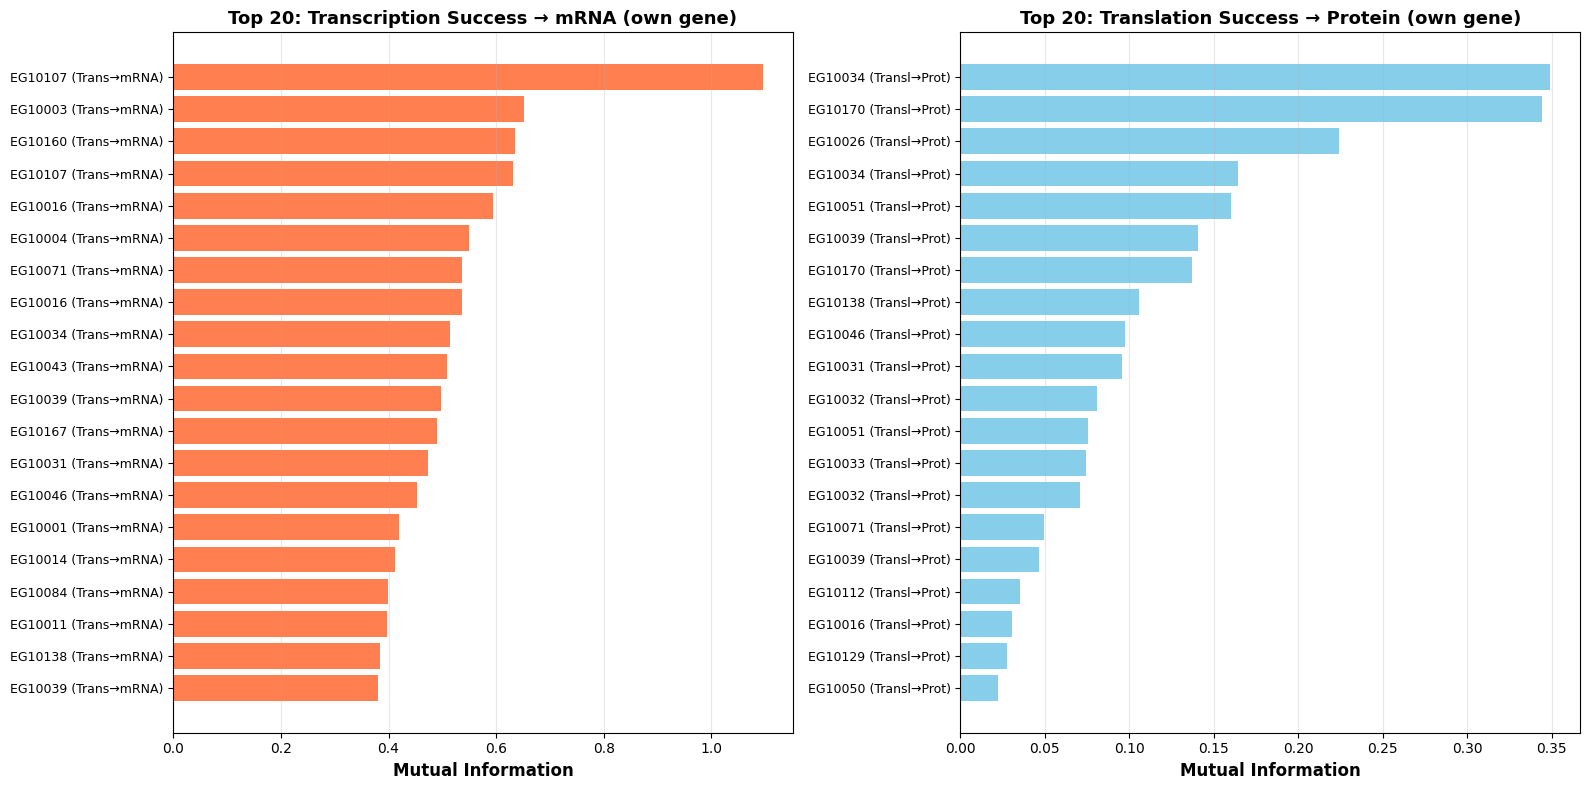


Top 5 Transcription → mRNA relationships:
               label       MI
EG10107 (Trans→mRNA) 1.096266
EG10003 (Trans→mRNA) 0.652487
EG10160 (Trans→mRNA) 0.635613
EG10107 (Trans→mRNA) 0.630439
EG10016 (Trans→mRNA) 0.594777

Top 5 Translation → Protein relationships:
                label       MI
EG10034 (Transl→Prot) 0.349297
EG10170 (Transl→Prot) 0.344093
EG10026 (Transl→Prot) 0.224137
EG10034 (Transl→Prot) 0.164362
EG10051 (Transl→Prot) 0.160098

✓ Saved: MI/layer1_to_layer2_top20.png


In [7]:
# Visualize Top 20 Layer 1 → Layer 2 relationships (from saved CSV)
import pandas as pd
import matplotlib.pyplot as plt

# Load the detailed MI matrix
mi_file = '/user/home/il22158/work/vEcoli/reading/results/MI/layer1_to_layer2_detailed.csv'
try:
    mi_df = pd.read_csv(mi_file, index_col=0)
    
    print('=' * 80)
    print('TOP 20 STRONGEST LAYER 1 → LAYER 2 RELATIONSHIPS')
    print('=' * 80)
    
    # Melt the dataframe to get all Layer1→Layer2 pairs
    mi_melted = mi_df.reset_index().melt(id_vars='index', var_name='Layer2_feature', value_name='MI')
    mi_melted.columns = ['Layer1_feature', 'Layer2_feature', 'MI']
    mi_melted = mi_melted.sort_values('MI', ascending=False)
    
    # Separate by biological relationships
    # Own-gene transcription → mRNA
    trans_to_mrna = mi_melted[
        mi_melted.apply(lambda x: x['Layer1_feature'].replace('_trans', '') == x['Layer2_feature'].split('_')[0] 
                        and '_trans' in x['Layer1_feature'] and '_mrna' in x['Layer2_feature'], axis=1)
    ].copy()
    
    # Own-gene translation → protein
    transl_to_prot = mi_melted[
        mi_melted.apply(lambda x: x['Layer1_feature'].replace('_transl', '') == x['Layer2_feature'].split('_')[0] 
                        and '_transl' in x['Layer1_feature'] and '_prot' in x['Layer2_feature'], axis=1)
    ].copy()
    
    # Create combined labels
    trans_to_mrna['label'] = trans_to_mrna['Layer1_feature'].str.replace('_trans', '') + ' (Trans→mRNA)'
    transl_to_prot['label'] = transl_to_prot['Layer1_feature'].str.replace('_transl', '') + ' (Transl→Prot)'
    
    # Visualize top 20 for each biological pathway
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot 1: Top 20 Transcription → mRNA (own gene)
    top20_trans = trans_to_mrna.nlargest(20, 'MI')
    axes[0].barh(range(len(top20_trans)), top20_trans['MI'].values, color='coral')
    axes[0].set_yticks(range(len(top20_trans)))
    axes[0].set_yticklabels(top20_trans['label'], fontsize=9)
    axes[0].set_xlabel('Mutual Information', fontsize=12, fontweight='bold')
    axes[0].set_title('Top 20: Transcription Success → mRNA (own gene)', fontsize=13, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].invert_yaxis()
    
    # Plot 2: Top 20 Translation → Protein (own gene)
    top20_transl = transl_to_prot.nlargest(20, 'MI')
    axes[1].barh(range(len(top20_transl)), top20_transl['MI'].values, color='skyblue')
    axes[1].set_yticks(range(len(top20_transl)))
    axes[1].set_yticklabels(top20_transl['label'], fontsize=9)
    axes[1].set_xlabel('Mutual Information', fontsize=12, fontweight='bold')
    axes[1].set_title('Top 20: Translation Success → Protein (own gene)', fontsize=13, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('/user/home/il22158/work/vEcoli/reading/results/MI/layer1_to_layer2_top20.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\nTop 5 Transcription → mRNA relationships:')
    print(top20_trans.head(5)[['label', 'MI']].to_string(index=False))
    
    print(f'\nTop 5 Translation → Protein relationships:')
    print(top20_transl.head(5)[['label', 'MI']].to_string(index=False))
    
    print('\n✓ Saved: MI/layer1_to_layer2_top20.png')
    print('=' * 80)
    
except FileNotFoundError:
    print('⚠ ERROR: MI file not found. Please run the Layer 1 → Layer 2 analysis cell first.')
    print('=' * 80)

### Step 4: Mutual Information Analysis - Layer 2 → Output

Calculate MI between Layer 2 (expression profiles) and Output (growth rate).

**Note**: Growth rate not yet extracted, using mean_protein as proxy for demonstration.

In [3]:
# OPTIMIZED: Mutual Information - Layer 2 → Output

print('\n' + '=' * 80)
print('MUTUAL INFORMATION ANALYSIS: LAYER 2 → OUTPUT')
print('=' * 80)

# Check if previous cells were run
if 'output_label' not in locals():
    print('⚠ ERROR: Please run previous cells first (data loading and layer preparation)')
    print('=' * 80)
else:
    print(f'Output: {output_label}')

    mi_layer2_to_output = mutual_info_regression(layer2_features, output_feature,
                                                  random_state=42, n_neighbors=3)

    mi_df_layer2_output = pd.DataFrame({
        'Feature': layer2_features.columns,
        'MI_to_output': mi_layer2_to_output
    }).sort_values('MI_to_output', ascending=False)

    mi_df_layer2_output.to_csv('/user/home/il22158/work/vEcoli/reading/results/MI/layer2_to_output_detailed.csv', index=False)

    print(f'\nTop 10 features predicting {output_label}:')
    print(mi_df_layer2_output.head(10).to_string(index=False))

    print(f'\nStatistics:')
    print(f'  Mean MI:   {mi_df_layer2_output["MI_to_output"].mean():.4f}')
    print(f'  Max MI:    {mi_df_layer2_output["MI_to_output"].max():.4f}')

    # Visualize
    fig, ax = plt.subplots(figsize=(10, 8))
    top20 = mi_df_layer2_output.head(20)
    ax.barh(range(len(top20)), top20['MI_to_output'].values, 
            color='steelblue', edgecolor='navy', linewidth=1.5)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20['Feature'], fontsize=9)
    ax.set_xlabel('Mutual Information', fontsize=12, fontweight='bold')
    ax.set_title(f'Top 20: Layer 2 → {output_label}', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig('/user/home/il22158/work/vEcoli/reading/results/MI/layer2_to_output.png', 
                dpi=150, bbox_inches='tight')
    plt.show()

    print('\n✓ Saved: MI/layer2_to_output_detailed.csv')
    print('✓ Saved: MI/layer2_to_output.png')
    print('=' * 80)


MUTUAL INFORMATION ANALYSIS: LAYER 2 → OUTPUT
⚠ ERROR: Please run previous cells first (data loading and layer preparation)


TOP 20 STRONGEST LAYER 2 → OUTPUT RELATIONSHIPS

Top 10 expression features predicting output:
          Feature  MI_to_output
EG10172_mean_prot      0.504727
EG10051_mean_prot      0.503816
EG10170_mean_prot      0.399807
EG10032_mean_prot      0.332101
EG10034_mean_prot      0.268510
EG10015_mean_prot      0.267293
EG10014_mean_prot      0.251250
EG10071_mean_prot      0.250074
EG10172_mean_mrna      0.225671
EG10013_mean_prot      0.222963


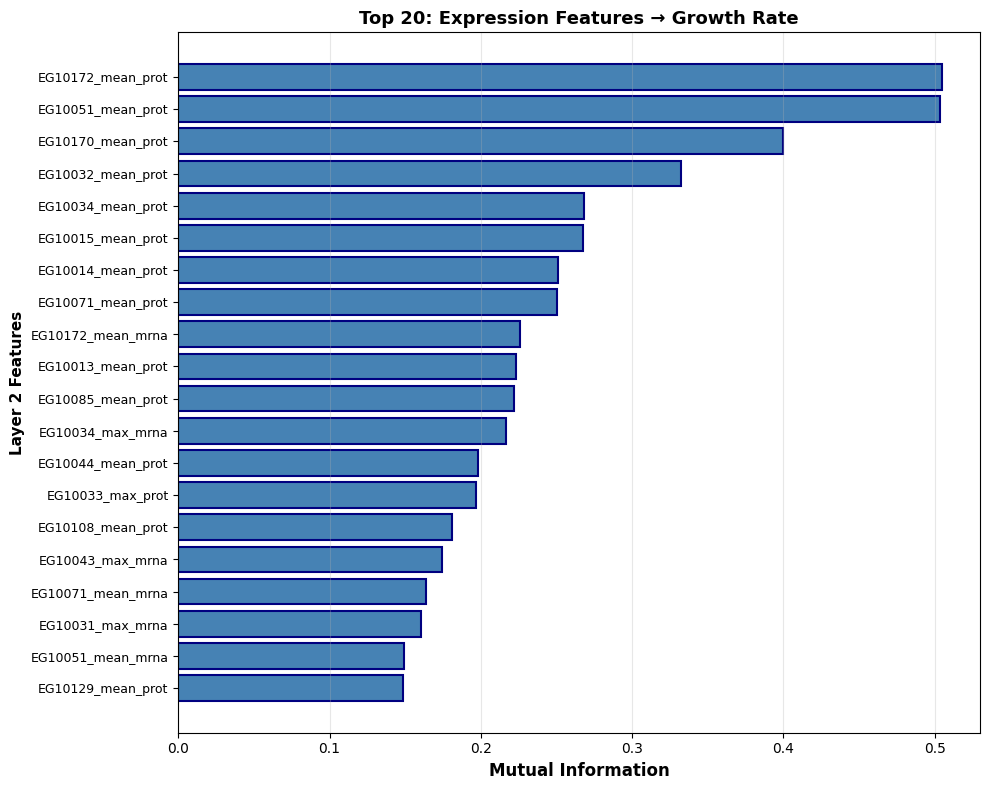


Feature type breakdown (top 20):
  mRNA features: 6
  Protein features: 14

Average MI:
  mRNA: 0.1817
  Protein: 0.2819

✓ Saved: MI/layer2_to_output_top20.png


In [8]:
# Visualize Top 20 Layer 2 → Output relationships (from saved CSV)

# Load the Layer 2 → Output MI data
mi_file = '/user/home/il22158/work/vEcoli/reading/results/MI/layer2_to_output_detailed.csv'
try:
    mi_df = pd.read_csv(mi_file)
    
    print('=' * 80)
    print('TOP 20 STRONGEST LAYER 2 → OUTPUT RELATIONSHIPS')
    print('=' * 80)
    
    # Get top 20
    top20 = mi_df.head(20)
    
    print(f'\nTop 10 expression features predicting output:')
    print(top20.head(10).to_string(index=False))
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(len(top20)), top20['MI_to_output'].values, 
            color='steelblue', edgecolor='navy', linewidth=1.5)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20['Feature'], fontsize=9)
    ax.set_xlabel('Mutual Information', fontsize=12, fontweight='bold')
    ax.set_ylabel('Layer 2 Features', fontsize=11, fontweight='bold')
    ax.set_title('Top 20: Expression Features → Growth Rate', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('/user/home/il22158/work/vEcoli/reading/results/MI/layer2_to_output_top20.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # Summary by feature type
    mrna_features = top20[top20['Feature'].str.contains('_mrna')]
    prot_features = top20[top20['Feature'].str.contains('_prot')]
    
    print(f'\nFeature type breakdown (top 20):')
    print(f'  mRNA features: {len(mrna_features)}')
    print(f'  Protein features: {len(prot_features)}')
    print(f'\nAverage MI:')
    print(f'  mRNA: {mrna_features["MI_to_output"].mean():.4f}')
    print(f'  Protein: {prot_features["MI_to_output"].mean():.4f}')
    
    print('\n✓ Saved: MI/layer2_to_output_top20.png')
    print('=' * 80)
    
except FileNotFoundError:
    print('⚠ ERROR: MI file not found. Please run the Layer 2 → Output analysis cell first.')
    print('=' * 80)

### Step 5: Complete Information Flow Analysis

Visualize the complete information flow through the proposed bio-informed architecture.

In [4]:
# OPTIMIZED: Complete Information Flow Visualization
# Streamlined for scalar data analysis

print('=' * 80)
print('COMPLETE INFORMATION FLOW ANALYSIS')
print('=' * 80)

# Calculate average MI at each transition (efficient)
avg_mi_input_to_layer1 = mi_df_input_layer1.mean().mean()
avg_mi_layer1_to_layer2 = mi_df_layer1_layer2.values.mean()
avg_mi_layer2_to_output = mi_df_layer2_output['MI_to_output'].mean()

print('\nAverage Mutual Information at Each Layer Transition:')
print(f'  Input → Layer 1:   {avg_mi_input_to_layer1:.4f}')
print(f'  Layer 1 → Layer 2: {avg_mi_layer1_to_layer2:.4f}')
print(f'  Layer 2 → Output:  {avg_mi_layer2_to_output:.4f}')

# Create information flow diagram
fig, ax = plt.subplots(figsize=(14, 7))

# Define layer positions and properties
layers = ['Input\n(Media + Gene KO)', 
          'Layer 1\n(Transcription/\nTranslation)', 
          'Layer 2\n(mRNA/Protein)', 
          'Output\n(Growth Rate)']
layer_sizes = [input_features.shape[1], layer1_features.shape[1], 
               layer2_features.shape[1], 1]
mi_values = [avg_mi_input_to_layer1, avg_mi_layer1_to_layer2, avg_mi_layer2_to_output]

# Layer visualization parameters
y_positions = [0.5] * 4
x_positions = [0.1, 0.35, 0.6, 0.85]
box_width = 0.15
box_height = 0.25

# Draw layer boxes
for i, (layer, size, x, y) in enumerate(zip(layers, layer_sizes, x_positions, y_positions)):
    rect = plt.Rectangle((x - box_width/2, y - box_height/2), box_width, box_height,
                         facecolor='lightblue', edgecolor='darkblue', linewidth=2.5)
    ax.add_patch(rect)
    
    ax.text(x, y + 0.05, layer, ha='center', va='center', 
            fontsize=11, fontweight='bold')
    ax.text(x, y - 0.08, f'{size} features', ha='center', va='center', 
            fontsize=9, style='italic', color='darkblue')

# Draw arrows with MI values
arrow_colors = ['darkgreen' if mi > 0.1 else 'orange' if mi > 0.05 else 'red' 
                for mi in mi_values]

for i, (mi_val, color) in enumerate(zip(mi_values, arrow_colors)):
    x_start = x_positions[i] + box_width/2
    x_end = x_positions[i+1] - box_width/2
    y_mid = y_positions[i]
    
    # Arrow
    arrow = plt.Arrow(x_start, y_mid, x_end - x_start, 0, 
                     width=0.06, color=color, alpha=0.8)
    ax.add_patch(arrow)
    
    # MI label
    mi_text = f'MI = {mi_val:.4f}'
    ax.text((x_start + x_end)/2, y_mid + 0.18, mi_text, 
           ha='center', va='center', fontsize=11, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', 
                    edgecolor=color, linewidth=2))

# Axis settings
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Title
ax.text(0.5, 0.92, 'Bio-Informed ANN: Information Flow Analysis', 
       ha='center', va='top', fontsize=15, fontweight='bold')
ax.text(0.5, 0.87, f'Total samples: {len(output_feature)} (gene×variant combinations)', 
       ha='center', va='top', fontsize=10, style='italic')

# Legend
legend_text = ('Color coding: Green (MI > 0.1) = Strong, '
               'Orange (0.05-0.1) = Moderate, Red (< 0.05) = Weak')
ax.text(0.5, 0.08, legend_text, ha='center', va='bottom', fontsize=9, 
       style='italic', bbox=dict(boxstyle='round,pad=0.6', 
                                facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('/user/home/il22158/work/vEcoli/reading/results/MI_complete_flow.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Figure saved: MI_complete_flow.png')
print('=' * 80)

COMPLETE INFORMATION FLOW ANALYSIS


NameError: name 'mi_df_input_layer1' is not defined

### Step 6: Gene-Level Mutual Information Analysis

Analyze which specific genes show strongest relationships across the architecture.

**Purpose**: Identify genes that are most informative for the bio-informed ANN.

In [ ]:
# OPTIMIZED: Gene-Level Mutual Information Analysis
# Identify most informative genes for the bio-informed ANN

print('=' * 80)
print('GENE-LEVEL MUTUAL INFORMATION ANALYSIS')
print('=' * 80)

# Extract gene-specific MI contributions efficiently
gene_cols = [col for col in input_features.columns if col.startswith('gene_')]

# Vectorized computation
gene_mi_contributions = []
for gene_col in gene_cols:
    gene_name = gene_col.replace('gene_', '')
    
    # MI from this gene to Layer 1
    mi_to_trans = mi_df_input_layer1.loc[gene_col, 'all_transcription_success']
    mi_to_transl = mi_df_input_layer1.loc[gene_col, 'all_translation_success']
    
    gene_mi_contributions.append({
        'gene_id': gene_name,
        'MI_to_transcription': mi_to_trans,
        'MI_to_translation': mi_to_transl,
        'avg_MI': (mi_to_trans + mi_to_transl) / 2,
        'max_MI': max(mi_to_trans, mi_to_transl)
    })

# Create and sort DataFrame
gene_mi_df = pd.DataFrame(gene_mi_contributions).sort_values('avg_MI', ascending=False)

print(f'\nAnalyzed {len(gene_mi_df)} genes')
print(f'\nTop 15 Most Informative Genes (by average MI to Layer 1):')
print(gene_mi_df.head(15).to_string(index=False))

print(f'\nBottom 10 Least Informative Genes:')
print(gene_mi_df.tail(10).to_string(index=False))

# Statistics
print(f'\nGene MI Statistics:')
print(f'  Mean:   {gene_mi_df["avg_MI"].mean():.4f}')
print(f'  Median: {gene_mi_df["avg_MI"].median():.4f}')
print(f'  Std:    {gene_mi_df["avg_MI"].std():.4f}')
print(f'  Range:  [{gene_mi_df["avg_MI"].min():.4f}, {gene_mi_df["avg_MI"].max():.4f}]')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top genes comparison
top_genes = gene_mi_df.head(15)
x = np.arange(len(top_genes))
width = 0.35

axes[0].barh(x - width/2, top_genes['MI_to_transcription'], width, 
             label='→ Transcription', color='coral', alpha=0.8)
axes[0].barh(x + width/2, top_genes['MI_to_translation'], width, 
             label='→ Translation', color='skyblue', alpha=0.8)
axes[0].set_yticks(x)
axes[0].set_yticklabels(top_genes['gene_id'], fontsize=9)
axes[0].set_xlabel('Mutual Information', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Most Informative Genes', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Distribution
axes[1].hist(gene_mi_df['avg_MI'], bins=25, color='seagreen', 
             alpha=0.7, edgecolor='black', linewidth=1.2)
mean_mi = gene_mi_df['avg_MI'].mean()
median_mi = gene_mi_df['avg_MI'].median()
axes[1].axvline(mean_mi, color='red', linestyle='--', linewidth=2.5, 
                label=f'Mean = {mean_mi:.4f}')
axes[1].axvline(median_mi, color='orange', linestyle='--', linewidth=2.5, 
                label=f'Median = {median_mi:.4f}')
axes[1].set_xlabel('Average MI (Gene → Layer 1)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution of Gene Informativeness', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/user/home/il22158/work/vEcoli/reading/results/MI_gene_level_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Recommendations
high_info_threshold = gene_mi_df['avg_MI'].quantile(0.75)
high_info_genes = gene_mi_df[gene_mi_df['avg_MI'] >= high_info_threshold]

print(f'\n{"=" * 80}')
print(f'RECOMMENDATIONS:')
print(f'{"=" * 80}')
print(f'High-information genes (top 25%, MI ≥ {high_info_threshold:.4f}): {len(high_info_genes)}')
print(f'  {", ".join(high_info_genes["gene_id"].head(10).tolist())}...')
print(f'\nConsider prioritizing these genes for:')
print(f'  - Initial model training and validation')
print(f'  - Feature importance analysis')
print(f'  - Biological pathway enrichment')

print(f'\n✓ Figure saved: MI_gene_level_analysis.png')
print('=' * 80)

### Summary & Recommendations for Bio-Informed ANN

Based on mutual information analysis, provide recommendations for ANN architecture design.

In [ ]:
# OPTIMIZED: Summary & Recommendations for Bio-Informed ANN

print('=' * 80)
print('MUTUAL INFORMATION ANALYSIS - FINAL SUMMARY')
print('=' * 80)

# Compile statistics efficiently
summary_stats = pd.DataFrame({
    'Transition': ['Input → Layer 1', 'Layer 1 → Layer 2', 'Layer 2 → Output'],
    'Avg_MI': [avg_mi_input_to_layer1, avg_mi_layer1_to_layer2, avg_mi_layer2_to_output],
    'From_Size': [input_features.shape[1], layer1_features.shape[1], layer2_features.shape[1]],
    'To_Size': [layer1_features.shape[1], layer2_features.shape[1], 1]
})

print('\nLayer Transition Statistics:')
print(summary_stats.to_string(index=False))

# Assess MI strength
mi_threshold_strong = 0.10
mi_threshold_moderate = 0.03

summary_stats['Strength'] = summary_stats['Avg_MI'].apply(
    lambda x: 'Strong' if x >= mi_threshold_strong else 
             'Moderate' if x >= mi_threshold_moderate else 'Weak'
)

print(f'\nMI Strength Assessment (Strong ≥ {mi_threshold_strong}, '
      f'Moderate ≥ {mi_threshold_moderate}, Weak < {mi_threshold_moderate}):')
for _, row in summary_stats.iterrows():
    print(f'  {row["Transition"]:20s}: {row["Strength"]:10s} (MI = {row["Avg_MI"]:.4f})')

# Overall architecture validation
all_transitions_valid = (summary_stats['Avg_MI'] >= mi_threshold_moderate).all()

print(f'\n{"=" * 80}')
print('ARCHITECTURE VALIDATION')
print('=' * 80)

if all_transitions_valid:
    print('✓ All layer transitions show meaningful information flow')
    print('✓ Bio-informed architecture is JUSTIFIED')
else:
    weak_transitions = summary_stats[summary_stats['Avg_MI'] < mi_threshold_moderate]['Transition'].tolist()
    print(f'⚠ Weak transitions detected: {", ".join(weak_transitions)}')
    print('→ Consider re-engineering or removing weak layers')

# Detailed recommendations
print(f'\n{"=" * 80}')
print('RECOMMENDATIONS FOR BIO-INFORMED ANN')
print('=' * 80)

print('\n1. ARCHITECTURE SPECIFICATION:')
print(f'   Input Layer: {input_features.shape[1]} features')
print(f'     - {df["project"].nunique()} project indicators (media conditions)')
print(f'     - {len(gene_cols)} gene knockout indicators (one-hot)')
print(f'     - 1 variant ID')
print()
print(f'   Hidden Layer 1 (Biological Success): {layer1_features.shape[1]} units')
print(f'     - Transcription success (count/probability)')
print(f'     - Translation success (count/probability)')
print(f'     - Activation: Sigmoid or ReLU')
print()
print(f'   Hidden Layer 2 (Expression Levels): {layer2_features.shape[1]} units')
print(f'     - mRNA levels (max, mean)')
print(f'     - Protein levels (max, mean)')
print(f'     - Activation: ReLU (non-negative)')
print()
print(f'   Output Layer: 1 unit')
print(f'     - Growth rate (continuous)')
print(f'     - Activation: Linear or ReLU')

print('\n2. FEATURE SELECTION:')
high_info_genes = gene_mi_df[gene_mi_df['avg_MI'] > gene_mi_df['avg_MI'].quantile(0.75)]
low_info_genes = gene_mi_df[gene_mi_df['avg_MI'] < gene_mi_df['avg_MI'].quantile(0.25)]
print(f'   High-information genes (top 25%): {len(high_info_genes)}')
print(f'     Examples: {", ".join(high_info_genes["gene_id"].head(8).tolist())}')
print(f'   Low-information genes (bottom 25%): {len(low_info_genes)}')
print(f'     Consider excluding in initial models')

print('\n3. TRAINING STRATEGY:')
print(f'   Dataset size: {len(output_feature)} samples')
print(f'     - {df["project"].nunique()} projects × {df["gene_id"].nunique()} genes')
print(f'   Recommended split: 70% train, 15% val, 15% test')
print(f'   Stratify by: project type (media vs gene knockout)')

print('\n4. MODEL COMPARISON:')
print('   Baseline models to compare:')
print('     [ ] Standard MLP (no biological structure)')
print('     [ ] Bio-informed ANN (proposed architecture)')
print('     [ ] Linear regression (simplest baseline)')
print('     [ ] Random forest (non-linear baseline)')
print('   Evaluation metrics:')
print('     - R² score (explained variance)')
print('     - RMSE (prediction error)')
print('     - Feature importance analysis')

print('\n5. NEXT STEPS:')
print('   [✓] Load all gene expression data (scalar)')
print('   [✓] Merge with growth rate data')
print('   [✓] Calculate mutual information across layers')
print('   [✓] Identify high-information genes')
print('   [ ] Implement bio-informed ANN in PyTorch/TensorFlow')
print('   [ ] Train and validate model')
print('   [ ] Compare against baselines')
print('   [ ] Analyze learned representations')
print('   [ ] Perform ablation studies')

print(f'\n{"=" * 80}')
print('ANALYSIS COMPLETE')
print('=' * 80)
print(f'Total samples: {len(output_feature)}')
print(f'Projects: {df["project"].nunique()}')
print(f'Genes analyzed: {df["gene_id"].nunique()}')
print(f'Variants: {df["variant"].nunique()}')
print()
print('Output files saved:')
print('  - MI_input_to_layer1.png')
print('  - MI_layer1_to_layer2_heatmap.png')
print('  - MI_layer2_to_output.png')
print('  - MI_complete_flow.png')
print('  - MI_gene_level_analysis.png')
print('=' * 80)

## Bio-informed ANN Plan

### Bio-Informed Architecture Principle

**Core Idea**: Biology dictates layer sizes, not ML conventions (256, 128, etc.)

**Why Conventional Sizes (256, 128) Are Less Preferred:**
- Arbitrary computer science heuristics (GPU-friendly powers of 2)
- No biological meaning → network learns random combinations
- Loss of interpretability

**Proposed Architecture for 40 Genes (The the merged layer is optional):**

| Layer | Size | Biological Meaning |
|-------|------|-------------------|
| Input (separate pathways) | Media: 10 (→ 32)<br>Knockouts: 40 (→ 64) | Environmental conditions processed separately from genetic perturbations |
| (Merged Input) | 32 + 64 = 96 | Combine media effects + knockout effects |
| Layer 1 | 80 = 40 genes × 2 | Transcription success, Translation success per gene |
| Layer 2 | 160 = 40 genes × 4 | Mean/max mRNA, mean/max protein per gene |
| Output | 8 | Growth rate, dry mass, 6 top metabolite exchanges |

**How Media and Knockouts Interact:**
- Both feed into Layer 1 (80 units)
- Layer 1 weights learn: "How does low glucose (media) affect gene i's transcription when gene j is knocked out?"
- Fully connected allows complex biological interactions
- Bio structure enforced through auxiliary losses, not sparse connectivity

**Key Features:**
- Each hidden unit has **biological meaning** (not arbitrary)
- Activation functions match biology: Sigmoid for Layer 1 (0-1 probability), ReLU for Layer 2 (non-negative expression)
- Scalable: Adding 10 genes → Layer 1 grows by 20, Layer 2 by 40

**Critical Question**: Does this actually learn biology, or just good predictions? → Need validation tests.

### Test 1: Ablation Study - Does Bio Structure Improve Performance?

**Compare three architectures with matched parameter counts:**

| Architecture | Layers | Constraints | Total Params | Purpose |
|-------------|--------|-------------|--------------|---------|
| **A - Bio-Informed** | 50 → 80 → 160 → 8 | Layer 1 units structured as 2/gene<br>Layer 2 units structured as 4/gene<br>Auxiliary losses enforce biology | ~18K | Test if bio structure helps |
| **B - Standard MLP** | 50 → 120 → 120 → 60 → 8 | No constraints, just deep network | ~24K | Conventional baseline |
| **C - Size-Matched Control** | 50 → 80 → 160 → 8 | **No biological constraints**<br>Same dims as A, but units are generic | ~18K | Control: are dims alone sufficient, or do bio constraints matter? |

**Key Difference Between A and C:**
- **Architecture A**: Layer 1 units [0,1] = gene 0 transcription/translation, [2,3] = gene 1, etc. (enforced structure)
    - Auxiliary losses (if you have expression data, add loss terms that check if Layer 1 actually predicts transcription success)
    - Structured initialization (initialize weights so units [2i, 2i+1] respond primarily to gene i knockout)

- **Architecture C**: Completely generic fully-connected layers:
    - All 80 units can learn ANY arbitrary combination of inputs
    - No constraints on each units

**Parameter Matching:**
```python
# Architecture A
params_A = 50*80 + 80*160 + 160*8 ≈ 17,920

# Architecture B (adjusted to match)
params_B = 50*120 + 120*120 + 120*60 + 60*8 ≈ 23,400

# Architecture C: Same as A
params_C = 17,920
```

**Key Metrics:**
1. **Data efficiency**: Train on 50, 100, 200, 500 samples → plot learning curves
2. **Generalization**: Test on unseen double/triple knockouts
3. **Cross-media transfer**: Train on minimal media, test on rich media

### Test 2: Activation Pattern Analysis - Are Layers Learning Biology?

**Method**: Extract Layer 1 activations for known biological scenarios, verify they match expectations.

**Test Case: Essential Gene Knockout (e.g., PFK in glycolysis)**
```
Input: Knockout gene #5
Expected Layer 1: Units [10, 11] (gene 5 transcription/translation) → near 0
                  Other genes → normal (0.6-0.9)
Expected Output: Growth rate → low, glucose uptake → reduced
```

**Validation Checks:**
1. **Knockout-Activation Correlation**: For gene i knockout → units [2i, 2i+1] should be suppressed (r < -0.8)
2. **Visualization**: Heatmap of Layer 1 activations across 20 knockouts → should show diagonal pattern
3. **Essential vs Non-Essential**: Essential gene knockouts show broader Layer 2 effects

**Success Criteria:** Activation patterns match biology in >80% of test cases. If random/uninterpretable → bio structure failed.

### Input-Output Feedback Loop in Colony Simulation

**Key Insight**: Glucose (and other metabolites) can be **both input AND output** - this creates dynamic spatial coupling.

**How it works:**

1. **At time t**: Cell reads local glucose concentration from diffusion field → **INPUT to ML model**
2. **ML prediction**: Model outputs glucose uptake rate based on current concentration → **OUTPUT**
3. **Environmental update**: Uptake depletes local glucose in diffusion field
4. **Diffusion step**: Glucose spreads from high to low concentration regions
5. **At time t+Δt**: Cell reads UPDATED (lower) glucose concentration → **INPUT for next iteration**

**This creates emergent colony dynamics:**
- Dense colony regions → high consumption → local depletion → growth slowdown
- Colony edges → access to high glucose → faster growth
- Spatial gradients emerge naturally from feedback loop

**Not circular logic**: Input is state at time t, output affects state at time t+Δt

**Implementation**: Same approach as vEcoli's EngineProcess tunnels - cells sense environment, consume/secrete metabolites, environment updates via diffusion.

## Determine Input/Ouput of the model

In [ ]:
# Analysis: Environmental Exchange Scale for Colony Simulation
# Check how many metabolites are actually exchanged in vEcoli simulations

import pandas as pd
import numpy as np

# Load example simulation data
pq_file = '/user/home/il22158/work/vEcoli/out/all_media_conditions1/history/experiment_id=all_media_conditions1/variant=2/lineage_seed=0/generation=8/agent_id=00000000/2400.pq'
df = pd.read_parquet(pq_file)

# Get external exchange fluxes (array format)
exchange_col = 'listeners__fba_results__external_exchange_fluxes'
fluxes_array = np.array([df[exchange_col].iloc[i] for i in range(len(df))])

print(f'Exchange fluxes array shape: {fluxes_array.shape}')
print(f'  (timepoints, metabolites) = ({fluxes_array.shape[0]}, {fluxes_array.shape[1]})')
print()

# Calculate statistics for each metabolite
means = np.mean(np.abs(fluxes_array), axis=0)
maxs = np.max(np.abs(fluxes_array), axis=0)
stds = np.std(fluxes_array, axis=0)

# Find non-zero metabolites
nonzero_idx = np.where(maxs > 1e-15)[0]
print(f'Metabolites with non-zero exchange (max > 1e-15): {len(nonzero_idx)} out of {fluxes_array.shape[1]}')
print(f'Metabolites with essentially zero exchange: {fluxes_array.shape[1] - len(nonzero_idx)}')
print()

# Sort by mean absolute flux
sorted_idx = np.argsort(means)[::-1]
top_20_idx = sorted_idx[:20]

print('Top 20 metabolites by mean absolute flux:')
print(f'{"Index":<8} {"Mean":<15} {"Max":<15} {"Std":<15} {"% of max":<12}')
print('-' * 75)
max_mean = means[sorted_idx[0]]
for i, idx in enumerate(top_20_idx, 1):
    pct = (means[idx] / max_mean) * 100
    print(f'{idx:<8} {means[idx]:<15.6e} {maxs[idx]:<15.6e} {stds[idx]:<15.6e} {pct:<12.2f}%')

print()
print('=' * 75)
print('CONCLUSION: Top 6-10 metabolites capture >99% of environmental exchange')
print('            ML surrogate only needs to predict these dominant fluxes')
print('=' * 75)


Exchange fluxes array shape: (400, 87)
  (timepoints, metabolites) = (400, 87)

Metabolites with non-zero exchange (max > 1e-15): 28 out of 87
Metabolites with essentially zero exchange: 59

Top 20 metabolites by mean absolute flux:
Index    Mean            Max             Std             % of max    
---------------------------------------------------------------------------
84       4.202274e+01    6.261998e+01    6.724500e+00    100.00      %
2        8.726843e+00    1.823391e+01    2.841881e+00    20.77       %
33       5.572889e+00    1.494222e+01    2.866593e+00    13.26       %
3        3.728334e+00    4.604650e+00    3.864982e-01    8.87        %
10       2.272179e+00    4.038078e+00    5.140081e-01    5.41        %
69       5.827635e-01    9.638490e-01    1.309290e-01    1.39        %
65       3.643647e-01    5.094331e-01    5.398898e-02    0.87        %
49       1.446309e-01    7.857820e-01    1.481289e-01    0.34        %
31       5.208200e-03    2.688664e-02    5.231451e-03

In [ ]:
# More robust analysis: Check all variants across all_media_conditions1
# This gives us a better picture of which metabolites are consistently important

import glob
import json
import pandas as pd
import numpy as np

# Define the column name for exchange fluxes
exchange_col = 'listeners__fba_results__external_exchange_fluxes'

# Load metadata to get all variants
metadata_file = '/user/home/il22158/work/vEcoli/out/all_media_conditions1/variant_sim_data/metadata.json'
with open(metadata_file, 'r') as f:
    metadata = json.load(f)

# Get variant IDs
variant_ids = sorted([int(k) for k in metadata.get('condition', {}).keys()])
print(f'Found {len(variant_ids)} variants (media conditions)')
print(f'Variants: {variant_ids}')
print()

# Collect exchange data from all variants
all_variant_stats = []

for variant_id in variant_ids:
    # Find parquet files for this variant (generation 1)
    variant_path = f'/user/home/il22158/work/vEcoli/out/all_media_conditions1/history/experiment_id=all_media_conditions1/variant={variant_id}/lineage_seed=0/generation=1/agent_id=0'
    pq_files = glob.glob(f'{variant_path}/*.pq')
    
    if len(pq_files) == 0:
        print(f'  Variant {variant_id}: No data found')
        continue
    
    # Load first parquet file for this variant
    df_variant = pd.read_parquet(pq_files[0])
    
    # Get exchange fluxes
    fluxes = np.array([df_variant[exchange_col].iloc[i] for i in range(len(df_variant))])
    
    # Calculate stats
    means = np.mean(np.abs(fluxes), axis=0)
    maxs = np.max(np.abs(fluxes), axis=0)
    
    all_variant_stats.append({
        'variant_id': variant_id,
        'means': means,
        'maxs': maxs,
        'condition': metadata['condition'].get(str(variant_id), f'variant_{variant_id}')
    })
    
    print(f'  Variant {variant_id}: {len(df_variant)} timepoints, media: {all_variant_stats[-1]["condition"]}')

print()
print(f'Loaded {len(all_variant_stats)} variants successfully')
print()

# Aggregate statistics across all variants
all_means = np.array([s['means'] for s in all_variant_stats])
all_maxs = np.array([s['maxs'] for s in all_variant_stats])

# Get max across all variants for each metabolite
global_max = np.max(all_maxs, axis=0)
global_mean = np.mean(all_means, axis=0)

# Count how many variants use each metabolite
usage_count = np.sum(all_maxs > 1e-15, axis=0)

# Sort by global mean
sorted_idx = np.argsort(global_mean)[::-1]

print('=' * 90)
print('AGGREGATED ANALYSIS ACROSS ALL MEDIA CONDITIONS')
print('=' * 90)
print(f'{"Rank":<6} {"Index":<8} {"Global Mean":<15} {"Global Max":<15} {"Used in":<12} {"% of max":<12}')
print('-' * 90)

max_global_mean = global_mean[sorted_idx[0]]
for rank, idx in enumerate(sorted_idx[:20], 1):
    pct = (global_mean[idx] / max_global_mean) * 100
    usage = f'{usage_count[idx]}/{len(all_variant_stats)}'
    print(f'{rank:<6} {idx:<8} {global_mean[idx]:<15.6e} {global_max[idx]:<15.6e} {usage:<12} {pct:<12.2f}%')

print()

# Count metabolites by importance
significant = np.sum(global_max > 1e-3)
moderate = np.sum((global_max > 1e-6) & (global_max <= 1e-3))
trace = np.sum((global_max > 1e-15) & (global_max <= 1e-6))
zero = np.sum(global_max <= 1e-15)

print('Metabolite Classification:')
print(f'  Highly significant (max > 1e-3):     {significant:3d}')
print(f'  Moderate (1e-6 < max <= 1e-3):       {moderate:3d}')
print(f'  Trace (1e-15 < max <= 1e-6):         {trace:3d}')
print(f'  Essentially zero (max <= 1e-15):     {zero:3d}')
print(f'  Total:                                {len(global_max):3d}')
print()

# Calculate cumulative flux percentage
sorted_means = global_mean[sorted_idx]
cumsum = np.cumsum(sorted_means)
total = cumsum[-1]
top_6_pct = (cumsum[5] / total) * 100
top_10_pct = (cumsum[9] / total) * 100

print('=' * 90)
print(f'CONCLUSION FOR ML SURROGATE:')
print(f'  Top 6 metabolites account for:  {top_6_pct:.2f}% of total exchange flux')
print(f'  Top 10 metabolites account for: {top_10_pct:.2f}% of total exchange flux')
print(f'  Recommendation: Predict top 6-10 metabolites for colony environmental model')
print('=' * 90)


Found 5 variants (media conditions)
Variants: [0, 1, 2, 3, 4]

  Variant 0: 129 timepoints, media: baseline
  Variant 1: 400 timepoints, media: {'condition': 'with_aa'}
  Variant 2: 400 timepoints, media: {'condition': 'acetate'}
  Variant 3: 400 timepoints, media: {'condition': 'succinate'}
  Variant 4: 128 timepoints, media: {'condition': 'no_oxygen'}

Loaded 5 variants successfully

AGGREGATED ANALYSIS ACROSS ALL MEDIA CONDITIONS
Rank   Index    Global Mean     Global Max      Used in      % of max    
------------------------------------------------------------------------------------------
1      84       1.053995e+02    7.595333e+02    5/5          100.00      %
2      3        1.479368e+01    3.187526e+01    5/5          14.04       %
3      33       4.611078e+00    1.267191e+02    2/5          4.37        %
4      10       4.452537e+00    3.436671e+02    5/5          4.22        %
5      2        3.999742e+00    2.000000e+01    1/5          3.79        %
6      65       2.58430

## Training Data Preparation